In [2]:
import pandas as pd
import numpy as np
import os

from PIL import Image
from matplotlib.image import imread
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

In [3]:
df = pd.read_csv("train_set.csv")
df.head()

,id_img,path,label
0,0,../data/images/train/angry\0.jpg,angry
1,1,../data/images/train/angry\1.jpg,angry
2,10,../data/images/train/angry\10.jpg,angry
3,10002,../data/images/train/angry\10002.jpg,angry
4,10016,../data/images/train/angry\10016.jpg,angry


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28821 entries, 0 to 28820
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id_img  28821 non-null  int64 
 1   path    28821 non-null  object
 2   label   28821 non-null  object
dtypes: int64(1), object(2)
memory usage: 675.6+ KB


In [5]:
df["path"] = df["path"].str.replace("/", "\\")
df["path"] = df["path"].str.replace("..\\", "")
df.head()

,id_img,path,label
0,0,data\images\train\angry\0.jpg,angry
1,1,data\images\train\angry\1.jpg,angry
2,10,data\images\train\angry\10.jpg,angry
3,10002,data\images\train\angry\10002.jpg,angry
4,10016,data\images\train\angry\10016.jpg,angry


In [6]:
df["label"].value_counts(normalize=True)

label
happy       0.248569
neutral     0.172860
sad         0.171333
fear        0.142361
angry       0.138545
surprise    0.111204
disgust     0.015128
Name: proportion, dtype: float64

In [7]:
df["label"].value_counts()

label
happy       7164
neutral     4982
sad         4938
fear        4103
angry       3993
surprise    3205
disgust      436
Name: count, dtype: int64

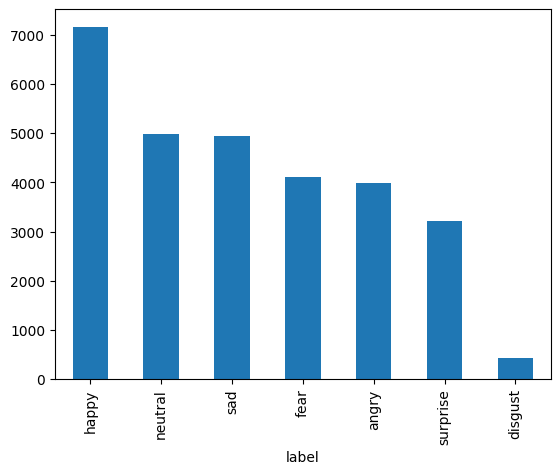

In [11]:
df['label'].value_counts().plot.bar();

In [22]:
os.getcwd()

'c:\\Users\\Administrador\\Desktop\\repositorios_agc\\repo_agc\\ONLINE_DS_THEBRIDGE_TRABAJOSAGC\\competiciones_kaggle\\emo_dataset'

In [29]:
lista_fotos_bn = []

for foto in df["path"]:
    # image = imread(foto)
    img = Image.open(foto).convert("L")
    img_resized = img.resize((48, 48))
    img_array = np.array(img_resized)

    img_array = img_array[..., np.newaxis]

    lista_fotos_bn.append(img_array)

print(len(lista_fotos_bn))

28821


In [34]:
X = np.array(lista_fotos_bn, dtype=np.float32)
X.shape

(28821, 48, 48, 1)

In [37]:
print(type(X[0][0][0][0]))

<class 'numpy.float32'>


In [39]:
encoder = OneHotEncoder()
y = encoder.fit_transform(df[["label"]]).toarray()
y

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(28821, 7))

In [40]:
np.save(os.path.join("datos_procesados", "X_bn.npy"), X)
np.save(os.path.join("datos_procesados", "y_bn.npy"), y)